# **Business Problem**

FLO wants to divide its customers into segments and determine marketing strategies according to these segments. To this end, customer behaviors will be defined and groups will be created according to clusters in these behaviors.

# **Dataset Story**

The dataset consists of information obtained from the past shopping behavior of customers who made their last purchases from Flo as OmniChannel (both online and offline shopping) in 2020 - 2021.

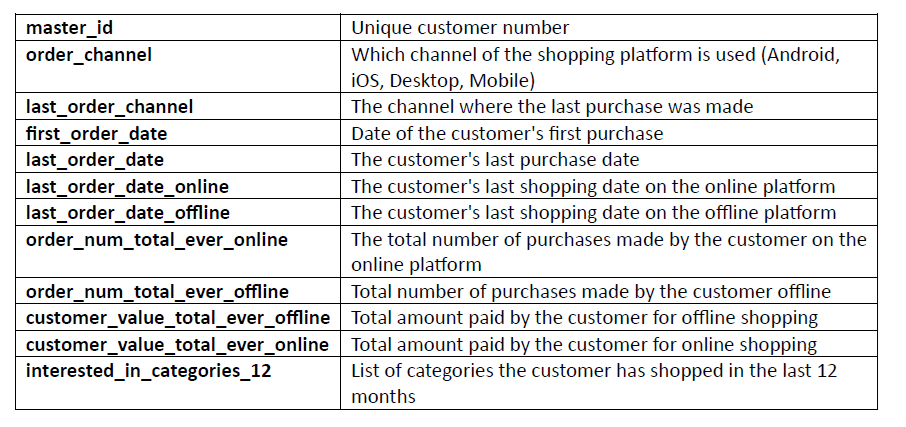

# **Preparing the Data**

We begin by importing the essential libraries for data analysis, visualization, and clustering.  
This includes tools like `pandas`, `numpy`, `matplotlib`, and `scikit-learn`, along with `yellowbrick` for elbow visualization.

In [15]:
!pip install yellowbrick

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

We load the dataset using `pandas` and preview the first few rows.  
This helps us understand the data structure and identify if there are any missing values or inconsistencies.

In [5]:
df = pd.read_csv("flo_data_20k.csv", index_col=0)

In [6]:
df.head()

,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
master_id,,,,,,,,,,,
cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN]
f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]"
1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]"
d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR]


In [8]:
df.isnull().sum()

,0
order_channel,0
last_order_channel,0
first_order_date,0
last_order_date,0
last_order_date_online,0
last_order_date_offline,0
order_num_total_ever_online,0
order_num_total_ever_offline,0
customer_value_total_ever_offline,0
customer_value_total_ever_online,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19945 entries, cc294636-19f0-11eb-8d74-000d3a38a36f to 740998d2-b1f7-11e9-89fa-000d3a38a36f
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_channel                      19945 non-null  object 
 1   last_order_channel                 19945 non-null  object 
 2   first_order_date                   19945 non-null  object 
 3   last_order_date                    19945 non-null  object 
 4   last_order_date_online             19945 non-null  object 
 5   last_order_date_offline            19945 non-null  object 
 6   order_num_total_ever_online        19945 non-null  float64
 7   order_num_total_ever_offline       19945 non-null  float64
 8   customer_value_total_ever_offline  19945 non-null  float64
 9   customer_value_total_ever_online   19945 non-null  float64
 10  interested_in_categories_12        19945 non-null  object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_num_total_ever_online,19945.0,3.110855,4.225647,1.00,1.00,2.00,4.00,200.00
order_num_total_ever_offline,19945.0,1.913913,2.062880,1.00,1.00,1.00,2.00,109.00
customer_value_total_ever_offline,19945.0,253.922597,301.532853,10.00,99.99,179.98,319.97,18119.14
customer_value_total_ever_online,19945.0,497.321690,832.601886,12.99,149.98,286.46,578.44,45220.13


Date-related features are converted into `datetime` format.  
This enables us to perform date arithmetic, such as calculating how recently a customer made a purchase.

In [12]:
date_cols = ["first_order_date", "last_order_date",
             "last_order_date_online", "last_order_date_offline"]

df[date_cols] = df[date_cols].apply(pd.to_datetime)

To segment customers, we use the RFM (Recency, Frequency, Monetary) model:

- **Recency**: Days since the customer's last purchase
- **Frequency**: Total number of purchases made by the customer
- **Monetary**: Total value of purchases made

These metrics capture customer engagement and are widely used in marketing analytics.

In [32]:
reference_date = pd.to_datetime("2021-06-01")

df["recency"] = (reference_date - df["last_order_date"]).dt.days
df["tenure"] = (reference_date - df["first_order_date"]).dt.days
df["order_num_total"] = df["order_num_total_ever_online"] + df["order_num_total_ever_offline"]
df["customer_value_total"] = df["customer_value_total_ever_online"] + df["customer_value_total_ever_offline"]

In [33]:
print(df[["recency", "tenure", "order_num_total", "customer_value_total"]].head())

                                      recency  tenure  order_num_total  \
master_id                                                                
cc294636-19f0-11eb-8d74-000d3a38a36f       95     214              5.0   
f431bd5a-ab7b-11e9-a2fc-000d3a38a36f      105    1574             21.0   
69b69676-1a40-11ea-941b-000d3a38a36f      186     552              5.0   
1854e56c-491f-11eb-806e-000d3a38a36f      135     146              2.0   
d6ea1074-f1f5-11e9-9346-000d3a38a36f       86     668              2.0   

                                      customer_value_total  
master_id                                                   
cc294636-19f0-11eb-8d74-000d3a38a36f                939.37  
f431bd5a-ab7b-11e9-a2fc-000d3a38a36f               2013.55  
69b69676-1a40-11ea-941b-000d3a38a36f                585.32  
1854e56c-491f-11eb-806e-000d3a38a36f                121.97  
d6ea1074-f1f5-11e9-9346-000d3a38a36f                209.98  


In [20]:
segmentation_df = df[["recency", "tenure", "order_num_total", "customer_value_total"]].copy()

print(segmentation_df.describe())

            recency        tenure  order_num_total  customer_value_total
count  19945.000000  19945.000000     19945.000000          19945.000000
mean     134.458360    801.302833         5.024768            751.244287
std      103.281149    523.396883         4.742707            895.402173
min        2.000000      5.000000         2.000000             44.980000
25%       43.000000    517.000000         3.000000            339.980000
50%      111.000000    651.000000         4.000000            545.270000
75%      202.000000    836.000000         6.000000            897.780000
max      367.000000   3060.000000       202.000000          45905.100000


# **Customer Segmentation with K-Means**

Before applying clustering algorithms, we scale the numerical features using `MinMaxScaler`.  
This step ensures that all variables contribute equally to the clustering process by bringing them into the same range (0 to 1).  
Without scaling, features with larger numerical values could dominate the clustering algorithm.

In [25]:
scaler = MinMaxScaler((0, 1))
segmentation_scaled = scaler.fit_transform(segmentation_df)

To find the optimal number of clusters for K-Means, we use the **Elbow Method**.  
This involves plotting the **Within-Cluster Sum of Squares (WCSS)** against the number of clusters (k).  
The "elbow" point on the graph indicates the ideal value of k — where adding more clusters does not significantly improve model performance.

In [34]:
sse = []  # sum of squared errors SSE/SSR/SSD

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(segmentation_scaled)
    sse.append(kmeans.inertia_)

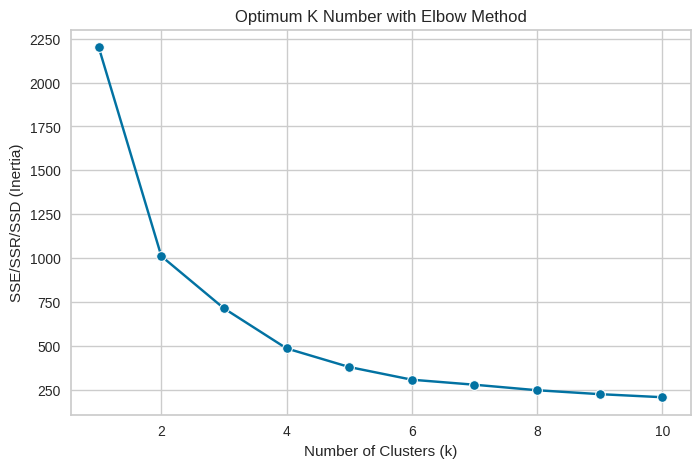

In [35]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, 11), y=sse, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE/SSR/SSD (Inertia)")
plt.title("Optimum K Number with Elbow Method")
plt.show()

We apply the K-Means algorithm to segment customers based on their RFM features.  
K-Means works by assigning each customer to the nearest cluster center and iteratively updating those centers until convergence.  
Each cluster represents a group of customers with similar behaviors.

In [29]:
k_optimum = 4
kmeans = KMeans(n_clusters=k_optimum, random_state=42)
clusters = kmeans.fit_predict(segmentation_scaled)

In [36]:
df["kmeans_segment"] = clusters

In [37]:
segment_analysis = df.groupby("kmeans_segment")[["recency", "tenure", "order_num_total", "customer_value_total"]].agg(["mean", "count", "median", "min", "max"])

print(segment_analysis)

                   recency                              tenure                \
                      mean count median  min  max         mean count  median   
kmeans_segment                                                                 
0               301.832170  3867  310.0  217  367   877.203517  3867   700.0   
1                43.180002  8161   37.0    2  104   601.072785  8161   603.0   
2               105.040900  1956   95.0    2  329  1982.433538  1956  1942.5   
3               160.499077  5961  160.0  100  241   638.625063  5961   623.0   

                           order_num_total                           \
                 min   max            mean count median  min    max   
kmeans_segment                                                        
0                253  3047        4.274114  3867    3.0  2.0   88.0   
1                  5  1495        4.988727  8161    4.0  2.0   83.0   
2               1214  3060        9.240286  1956    7.0  2.0  202.0   
3            

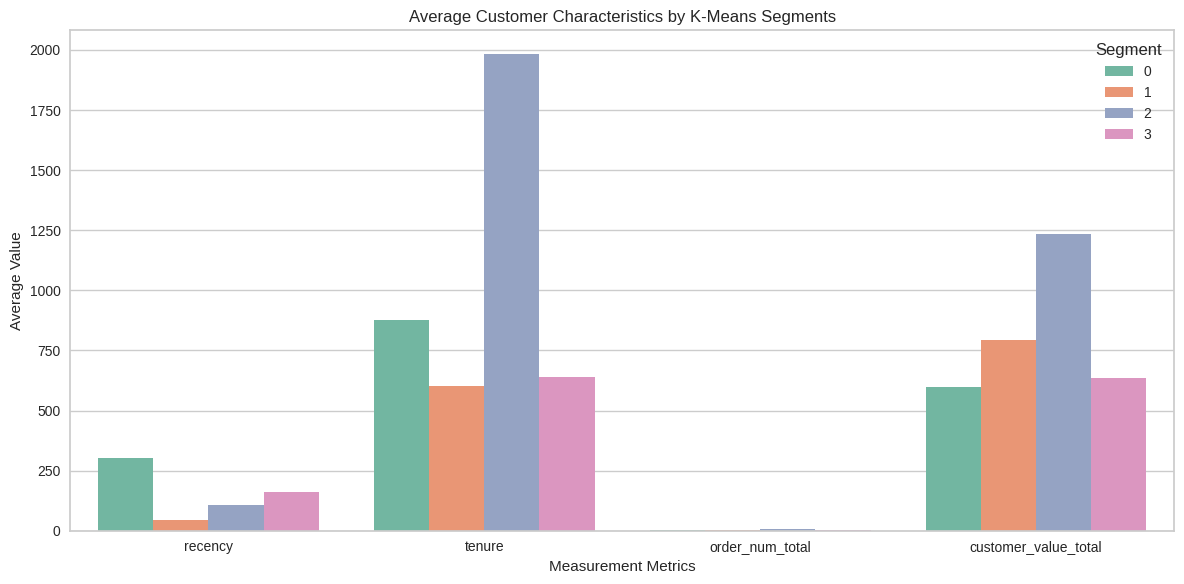

In [61]:
segment_df = df.groupby("kmeans_segment")[["recency", "tenure", "order_num_total", "customer_value_total"]].mean().reset_index()
segment_df["segment"] = segment_df["kmeans_segment"]

segment_melted = segment_df.melt(id_vars="segment",
                                  value_vars=["recency", "tenure", "order_num_total", "customer_value_total"],
                                  var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_melted, x="Metric", y="Value", hue="segment", palette="Set2")
plt.title("Average Customer Characteristics by K-Means Segments")
plt.xlabel("Measurement Metrics")
plt.ylabel("Average Value")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

# **Customer Segmentation with Hierarchical Clustering**

As an alternative to K-Means, we also apply **Hierarchical Clustering**, which builds a tree-like structure of clusters using a method called linkage.  
This approach does not require pre-defining the number of clusters and provides a visual output called a **dendrogram**.  
The dendrogram helps us understand the nested structure and possible merging points between clusters.

In [54]:
linked = linkage(segmentation_scaled, method='ward')

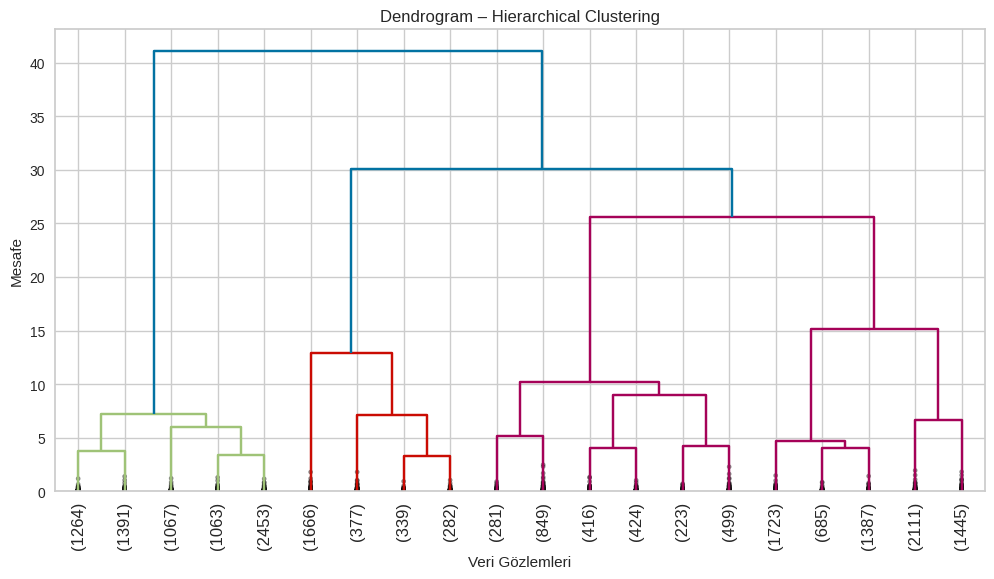

In [55]:
plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=90,
           leaf_font_size=12,
           show_contracted=True)
plt.title("Dendrogram – Hierarchical Clustering")
plt.xlabel("Data Observations")
plt.ylabel("Distance")
plt.show()

In [56]:
h_clusters = fcluster(linked, t=4, criterion='maxclust')

After clustering, each customer is assigned a segment label.  
To make the results actionable for marketing teams, we interpret the characteristics of each cluster (e.g., high-value, loyal customers vs. new or inactive customers)  
and assign meaningful names to the segments. These names help in designing targeted campaigns and strategic decisions.

In [57]:
df["hierarchical_segment"] = h_clusters

In [58]:
hier_segment_analysis = df.groupby("hierarchical_segment")[["recency", "tenure", "order_num_total", "customer_value_total"]].agg(["mean", "count", "median", "min", "max"])

print(hier_segment_analysis)

                         recency                              tenure        \
                            mean count median  min  max         mean count   
hierarchical_segment                                                         
1                      39.176568  7238   33.0    2  100   564.710279  7238   
2                     322.119369  2664  326.0  203  367  1027.455330  2664   
3                     101.622585  2692   94.0    2  262  1712.736999  2692   
4                     172.291933  7351  169.0   73  336   618.525779  7351   

                                        order_num_total                    \
                      median  min   max            mean count median  min   
hierarchical_segment                                                        
1                      586.0    5  1203        4.741779  7238    4.0  2.0   
2                      768.0  312  3047        4.377252  2664    3.0  2.0   
3                     1585.0   55  3060        9.003343  2692    7.0

Based on the customer segmentation analysis, we can now:

- Identify the most valuable customer groups
- Design personalized marketing strategies
- Improve customer retention and engagement
- Allocate marketing resources more efficiently

This segmentation model serves as a foundation for data-driven customer relationship management (CRM).

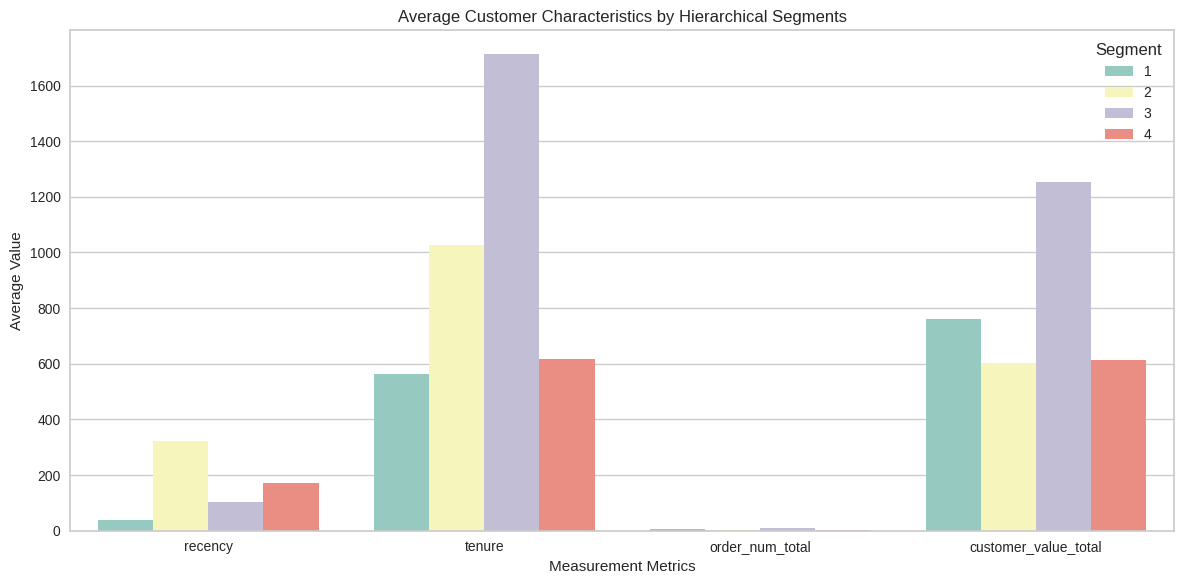

In [63]:
hier_segment_df = df.groupby("hierarchical_segment")[["recency", "tenure", "order_num_total", "customer_value_total"]].mean().reset_index()
hier_segment_df["segment"] = hier_segment_df["hierarchical_segment"]

hier_segment_melted = hier_segment_df.melt(id_vars="segment",
                                            value_vars=["recency", "tenure", "order_num_total", "customer_value_total"],
                                            var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 6))
sns.barplot(data=hier_segment_melted, x="Metric", y="Value", hue="segment", palette="Set3")
plt.title("Average Customer Characteristics by Hierarchical Segments")
plt.xlabel("Measurement Metrics")
plt.ylabel("Average Value")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

# **Marketing Strategies Suggestions**

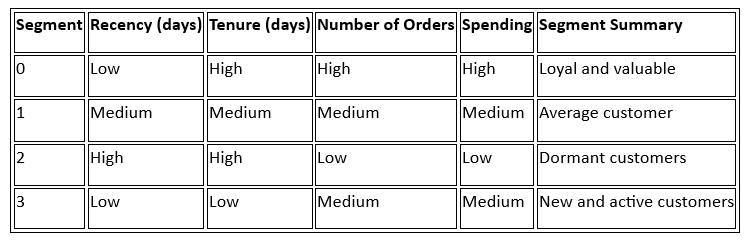

🟩🟩 **Segment 0 – Loyal and Valued Customers**

Features: Long-time customer, recent purchases, high spending and number of orders.

Strategy:

* VIP customer programs (reward points, special discounts).

* Priority customer support.

* Loyalty campaigns (e.g. 1 free for every 10 purchases).

* Birthday/special day coupons.

* First introduction of new products.

🟨🟨 **Segment 1 – Average Customers**

Characteristics: Neither very loyal nor churning, average spend and activity.

Strategy:

* Personalized campaigns with the theme “Welcome back!”

* “Bundle” recommendations to increase average basket size.

* Re-engagement with social media and email campaigns.

* Cross-sell opportunities with trial products.

🟥🟥 **Segment 2 – Sleeping Customers**

Features: Long time no shopper, low order and spend.

Strategy:

* “We miss you!” themed reactivation campaigns.

* High discount for first purchase.

* Category specific coupons (based on past purchases).

* Reminder triggers via SMS or mobile notification.

🟦🟦 **Segment 3 – New and Active Customers**

Features: New to the system but shopped in a short time.

Strategy:

* Welcome campaign + discount on 2nd shopping.

* “Were you satisfied with your first shopping?” survey and satisfaction coupon.

* Expand areas of interest with category promotions.

* Guidance with in-app notifications (favorite products, fast delivery, etc.)